## **1. Setup & Data Loading**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

np.random.seed(42)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Titanic/titanic.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum())

Dataset shape: (891, 12)

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


## **2. Exploratory Data Analysis**

In [4]:
print("Dataset Statistics:")
print(df.describe())

print(f"\nSurvival Distribution:")
print(df['Survived'].value_counts())
print(f"\nSurvival Rate: {df['Survived'].mean():.2%}")

Dataset Statistics:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  

Survival Distribution:
Survived
0    549
1    342
Name: coun

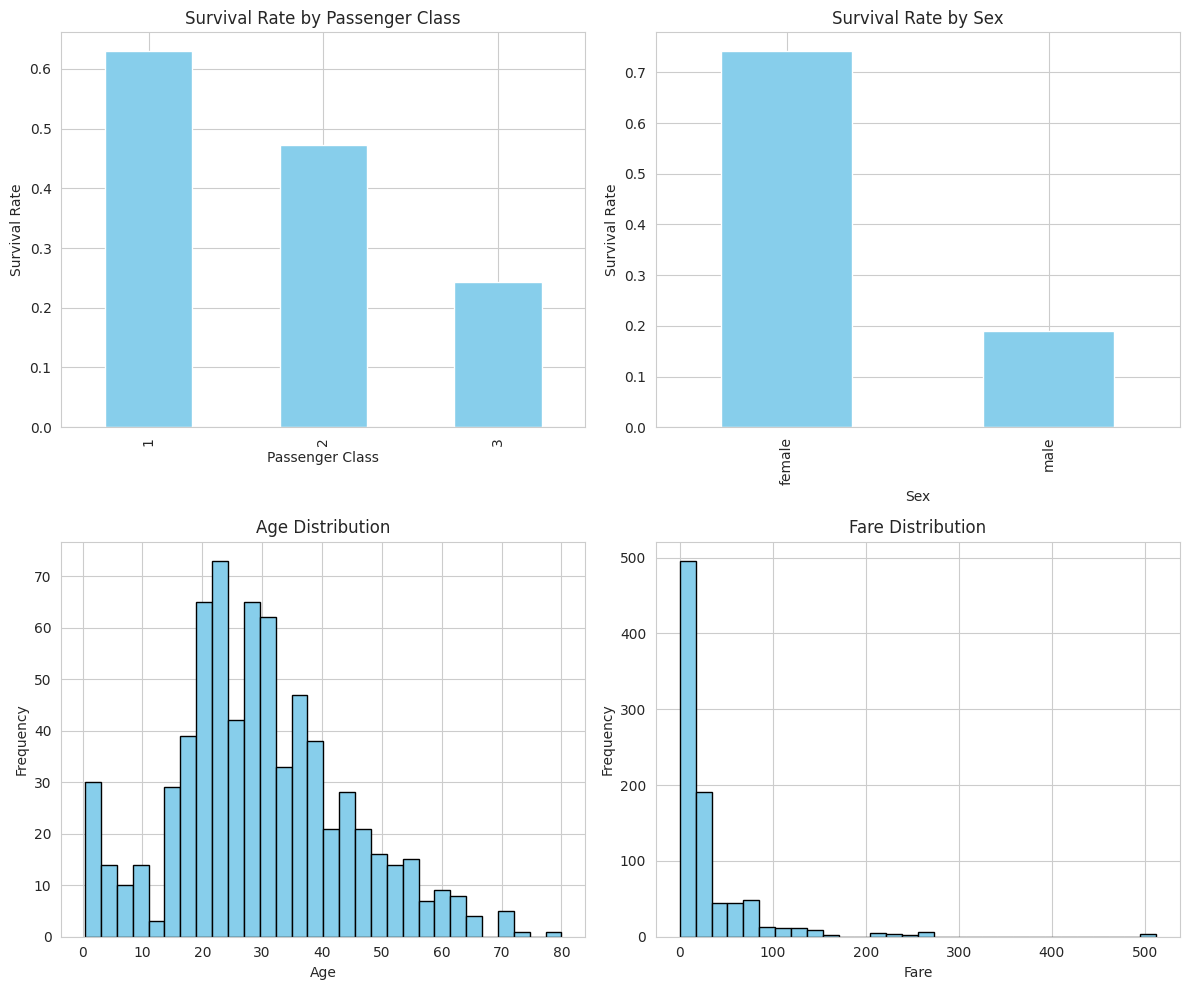

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

df.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Survival Rate by Passenger Class')
axes[0, 0].set_ylabel('Survival Rate')
axes[0, 0].set_xlabel('Passenger Class')

df.groupby('Sex')['Survived'].mean().plot(kind='bar', ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Survival Rate by Sex')
axes[0, 1].set_ylabel('Survival Rate')
axes[0, 1].set_xlabel('Sex')

df['Age'].hist(ax=axes[1, 0], bins=30, color='skyblue', edgecolor='black')
axes[1, 0].set_title('Age Distribution')
axes[1, 0].set_xlabel('Age')
axes[1, 0].set_ylabel('Frequency')

df['Fare'].hist(ax=axes[1, 1], bins=30, color='skyblue', edgecolor='black')
axes[1, 1].set_title('Fare Distribution')
axes[1, 1].set_xlabel('Fare')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## **3. Data Preprocessing**

In [6]:
def preprocess_data(df):
    df = df.copy()

    df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(
        lambda x: x.fillna(x.median())
    )
    df['Age'].fillna(df['Age'].median(), inplace=True)
    df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
    df.drop('Cabin', axis=1, inplace=True)
    df.drop('Ticket', axis=1, inplace=True)

    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    title_counts = df['Title'].value_counts()
    rare_titles = title_counts[title_counts < 10].index
    df['Title'] = df['Title'].replace(rare_titles, 'Rare')

    title_mapping = {
        'Mr': 1, 'Miss': 2, 'Mrs': 3, 'Master': 4,
        'Rare': 5, 'Ms': 2, 'Mme': 3, 'Mlle': 2
    }
    df['Title'] = df['Title'].map(title_mapping)

    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

    df['AgeGroup'] = pd.cut(df['Age'],
                              bins=[-1, 5, 12, 18, 35, 60, 120],
                              labels=[1, 2, 3, 4, 5, 6])
    df['AgeGroup'] = df['AgeGroup'].astype(int)

    df['FarePerPerson'] = df['Fare'] / (df['FamilySize']).clip(1)

    df['FareBand'] = pd.qcut(df['Fare'], q=4, labels=[1, 2, 3, 4], duplicates='drop')
    df['FareBand'] = df['FareBand'].astype(int)


    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
    embarked_mapping = {'S': 1, 'C': 2, 'Q': 3}
    df['Embarked'] = df['Embarked'].map(embarked_mapping)

    columns_to_drop = ['PassengerId', 'Name', 'Age', 'Fare']
    df.drop(columns_to_drop, axis=1, inplace=True)

    return df

df_processed = preprocess_data(df)

/tmp/ipykernel_11713/2721357274.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_11713/2721357274.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [7]:
print(f"Shape: {df_processed.shape}")
print(f"Missing values: {df_processed.isnull().sum().sum()}")

Shape: (891, 12)
Missing values: 0


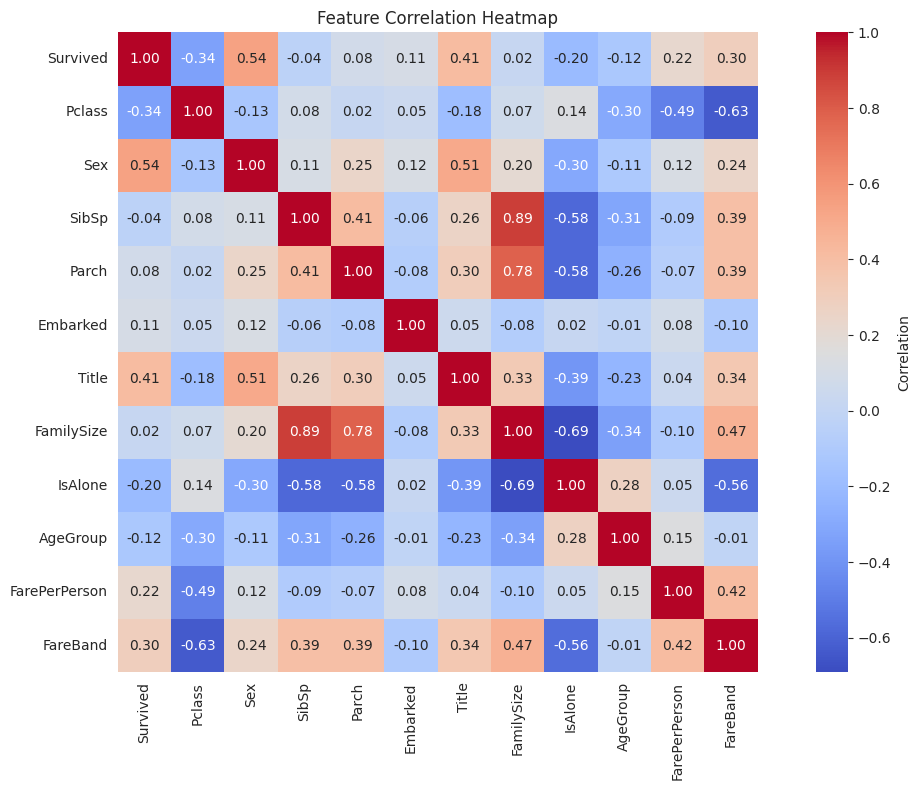

In [8]:
correlation_matrix = df_processed.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, cbar_kws={'label': 'Correlation'})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## **4. Train-Test Split & Feature Scaling**

In [9]:
X = df_processed.drop('Survived', axis=1)
y = df_processed['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Train set size: (712, 11)
Test set size: (179, 11)


In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## **5. Model Training & Evaluation**

In [11]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    if hasattr(model, 'predict_proba'):
        y_test_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_test_proba)
    else:
        roc_auc = None

    results = {
        'Model': model_name,
        'Train Accuracy': accuracy_score(y_train, y_train_pred),
        'Test Accuracy': accuracy_score(y_test, y_test_pred),
        'Precision': precision_score(y_test, y_test_pred),
        'Recall': recall_score(y_test, y_test_pred),
        'F1-Score': f1_score(y_test, y_test_pred),
        'ROC-AUC': roc_auc
    }

    return results, y_test_pred, y_test_proba if hasattr(model, 'predict_proba') else None

all_results = []
predictions_dict = {}
probabilities_dict = {}

In [12]:
# Model 1: Gradient Boosting
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=2,
    subsample=0.8,
    random_state=42
)
gb_model.fit(X_train, y_train)

gb_results, gb_pred, gb_proba = evaluate_model(gb_model, X_train, X_test, y_train, y_test, 'Gradient Boosting')
all_results.append(gb_results)
predictions_dict['Gradient Boosting'] = gb_pred
probabilities_dict['Gradient Boosting'] = gb_proba

print(f"\nGradient Boosting Results:")
for key, value in gb_results.items():
    if key != 'Model':
        print(f"{key}: {value:.4f}")


Gradient Boosting Results:
Train Accuracy: 0.8989
Test Accuracy: 0.8380
Precision: 0.8030
Recall: 0.7681
F1-Score: 0.7852
ROC-AUC: 0.8514


In [13]:
# Model 2: Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_results, rf_pred, rf_proba = evaluate_model(rf_model, X_train, X_test, y_train, y_test, 'Random Forest')
all_results.append(rf_results)
predictions_dict['Random Forest'] = rf_pred
probabilities_dict['Random Forest'] = rf_proba

print(f"\nRandom Forest Results:")
for key, value in rf_results.items():
    if key != 'Model':
        print(f"{key}: {value:.4f}")


Random Forest Results:
Train Accuracy: 0.9017
Test Accuracy: 0.8324
Precision: 0.8197
Recall: 0.7246
F1-Score: 0.7692
ROC-AUC: 0.8419


In [14]:
# Model 3: Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)
lr_model.fit(X_train_scaled, y_train)

lr_results, lr_pred, lr_proba = evaluate_model(lr_model, X_train_scaled, X_test_scaled, y_train, y_test, 'Logistic Regression')
all_results.append(lr_results)
predictions_dict['Logistic Regression'] = lr_pred
probabilities_dict['Logistic Regression'] = lr_proba

print(f"\nLogistic Regression Results:")
for key, value in lr_results.items():
    if key != 'Model':
        print(f"{key}: {value:.4f}")


Logistic Regression Results:
Train Accuracy: 0.8118
Test Accuracy: 0.8212
Precision: 0.7403
Recall: 0.8261
F1-Score: 0.7808
ROC-AUC: 0.8551


In [15]:
# Model 4: Support Vector Machine
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)
svm_model.fit(X_train_scaled, y_train)

svm_results, svm_pred, svm_proba = evaluate_model(svm_model, X_train_scaled, X_test_scaled, y_train, y_test, 'SVM')
all_results.append(svm_results)
predictions_dict['SVM'] = svm_pred
probabilities_dict['SVM'] = svm_proba

print(f"\nSVM Results:")
for key, value in svm_results.items():
    if key != 'Model':
        print(f"{key}: {value:.4f}")


SVM Results:
Train Accuracy: 0.8455
Test Accuracy: 0.8212
Precision: 0.8246
Recall: 0.6812
F1-Score: 0.7460
ROC-AUC: 0.8726


## **6. Model Comparison & Analysis**

In [16]:
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

print("\n\nModel Comparison:")
display_df = results_df.copy()
for col in display_df.columns[1:]:
    if col != 'Model':
        display_df[col] = (display_df[col] * 100).round(2).astype(str) + '%'
print(display_df.to_string(index=False))



Model Comparison:
              Model Train Accuracy Test Accuracy Precision Recall F1-Score ROC-AUC
  Gradient Boosting         89.89%         83.8%     80.3% 76.81%   78.52%  85.14%
      Random Forest         90.17%        83.24%    81.97% 72.46%   76.92%  84.19%
Logistic Regression         81.18%        82.12%    74.03% 82.61%   78.08%  85.51%
                SVM         84.55%        82.12%    82.46% 68.12%    74.6%  87.26%


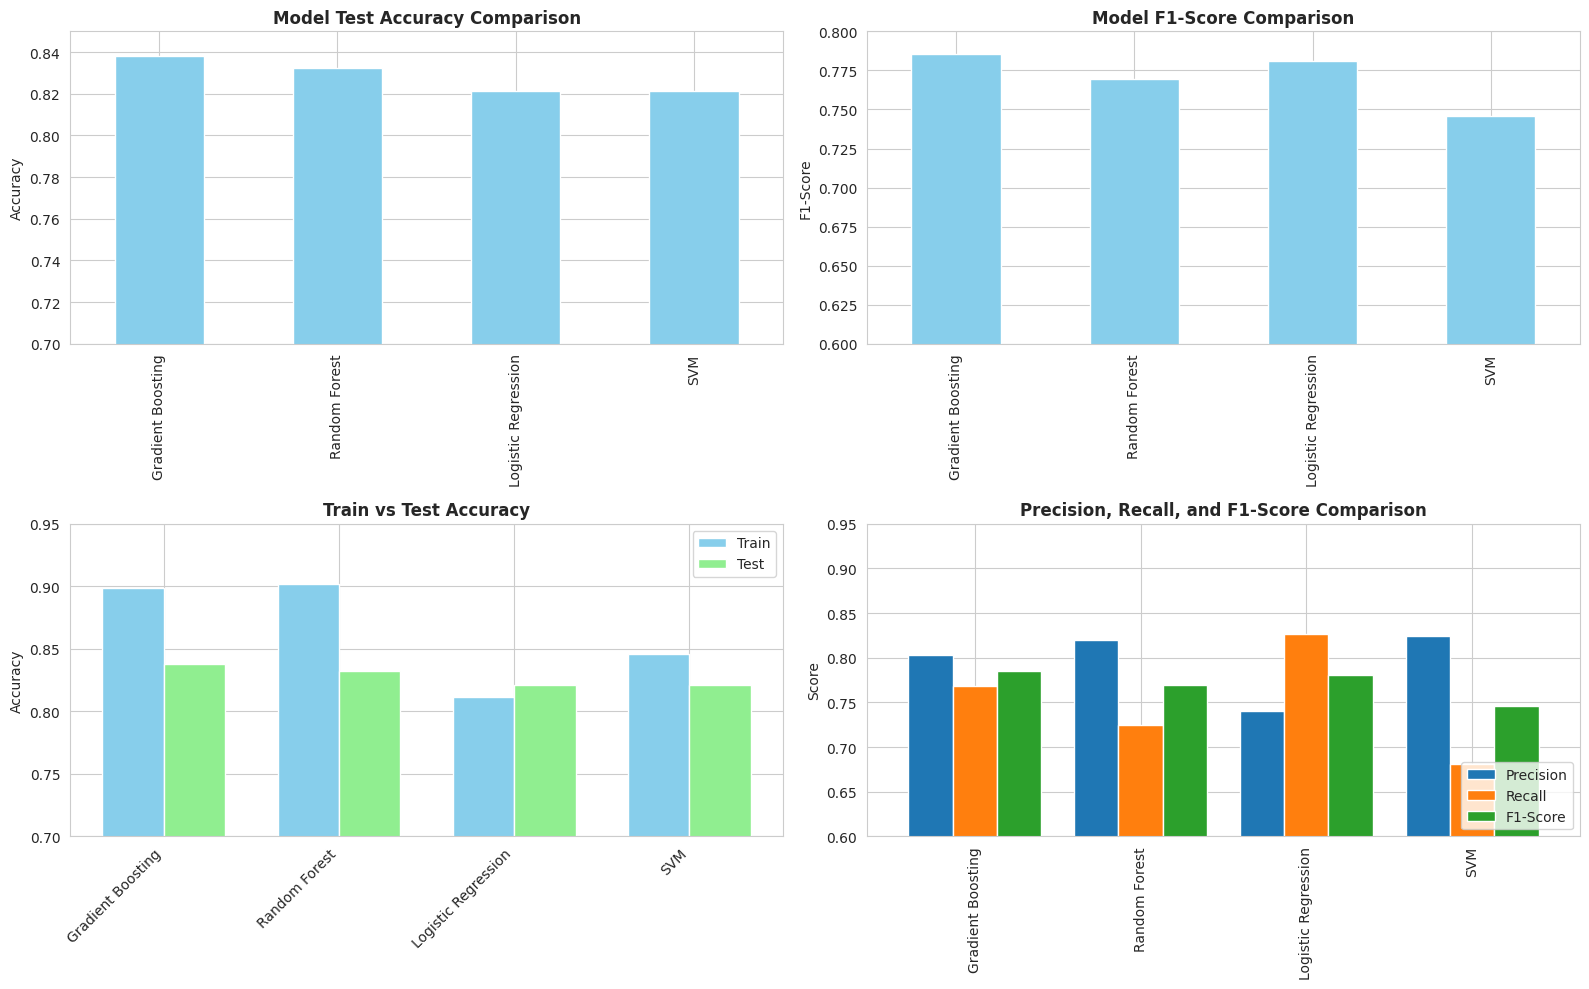

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
results_df.plot(x='Model', y='Test Accuracy', kind='bar', ax=ax, legend=False, color='skyblue')
ax.set_title('Model Test Accuracy Comparison', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_xlabel('')
ax.set_ylim([0.7, 0.85])

ax = axes[0, 1]
results_df.plot(x='Model', y='F1-Score', kind='bar', ax=ax, legend=False, color='skyblue')
ax.set_title('Model F1-Score Comparison', fontsize=12, fontweight='bold')
ax.set_ylabel('F1-Score')
ax.set_xlabel('')
ax.set_ylim([0.6, 0.8])

ax = axes[1, 0]
x = np.arange(len(results_df))
width = 0.35
ax.bar(x - width/2, results_df['Train Accuracy'], width, label='Train', color='skyblue')
ax.bar(x + width/2, results_df['Test Accuracy'], width, label='Test', color='lightgreen')
ax.set_title('Train vs Test Accuracy', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax.legend()
ax.set_ylim([0.7, 0.95])

ax = axes[1, 1]
results_df[['Model', 'Precision', 'Recall', 'F1-Score']].set_index('Model').plot(
    kind='bar', ax=ax, width=0.8
)
ax.set_title('Precision, Recall, and F1-Score Comparison', fontsize=12, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xlabel('')
ax.legend(loc='lower right')
ax.set_ylim([0.6, 0.95])

plt.tight_layout()
plt.show()

In [18]:
best_model_name = results_df.iloc[0]['Model']
best_model_results = results_df.iloc[0]

print(f"Best Model: {best_model_name}")

for key, value in best_model_results.items():
    if key != 'Model':
        print(f"{key:20s}: {value:.4f}")

best_predictions = predictions_dict[best_model_name]
best_probabilities = probabilities_dict[best_model_name]

Best Model: Gradient Boosting
Train Accuracy      : 0.8989
Test Accuracy       : 0.8380
Precision           : 0.8030
Recall              : 0.7681
F1-Score            : 0.7852
ROC-AUC             : 0.8514
